# Hand-engineered features y reconocimiento robusto de objetos

## Autores

* **Juan Diego Gallego Nicolás (jdiego.gallego@um.es)**
* **Óscar Vera López (oscar.veral@um.es)**

# Introducción al notebook

Este notebook es la tercera parte de una serie de cinco que constituye nuestra práctica para la asignatura de Visión Artificial del Máster en Inteligencia Artificial de la Universidad de Murcia. Alguno de los métodos/resultados que aquí se utilizan pueden estar comentados en un notebook anterior. Para el correcto funcionamiento del mismo es necesario instalar el paquete del proyecto siguiendo las instrucciones del [repositorio de GitHub](https://github.com/oscarveral/vision.git).

TODO. Descripcion del contenido del notebook.

Al final del documento, incluimos un apartado de conclusiones y justificación de los ítems de bloques cubiertos por nuestro trabajo. También dejamos un párrafo explicando el papel de la IA generativa en la elaboración del mismo.


# Configuración e inicialización

## Importación de librerías

En el siguiente fragmento de código se incluyen las importaciones necesarias para la ejecución de todos los bloques de código del notebook. Recuerde crear un entorno virtual con el proyecto instalado (Ejecutar "pip install -e ." en el directorio raíz del proyecto) y seguir las instrucciones del fichero README.md.

In [1]:
# Librerias externas.
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np

# Librerías propias
from dgst.utils.loader import *
from dgst.utils.processor import *
from dgst.utils.features import *
from dgst.utils.fuser import *
from dgst.utils.descriptors import *
from dgst.utils.matcher import *

## Definición de funciones auxiliares

A continuación incluimos las definiciones de una serie de funciones para simplificar la salida de las celdas del notebook.

In [2]:
# Función para mostrar las imágenes en una cuadrícula
import numpy as np
import cv2 as cv

def plot_images(images, titles=None, grid_shape=(3, 4), figsize=None):
    if figsize is None:
        figsize = (grid_shape[1]*3, grid_shape[0]*2)

    fig, axes = plt.subplots(*grid_shape, figsize=figsize)

    # Normalizar `axes` a un iterador plano
    if isinstance(axes, np.ndarray):
        iter_axes = axes.flat
    else:
        # Cuando subplots devuelve un solo Axes (no array)
        iter_axes = iter([axes])

    for i, ax in enumerate(iter_axes):
        if i >= len(images):
            ax.axis('off')
            continue

        image = images[i]
        # Si es un objeto con get_image(), usarlo
        if not isinstance(image, np.ndarray) and hasattr(image, 'get_image'):
            try:
                image = image.get_image()
            except Exception:
                image = None

        if image is None:
            ax.text(0.5, 0.5, 'No image', ha='center', va='center')
        else:
            # Mostrar según dimensiones
            if isinstance(image, np.ndarray):
                if image.ndim == 2:
                    ax.imshow(image, cmap='gray')
                elif image.ndim == 3:
                    # Intentar convertir BGR->RGB si procede
                    try:
                        ax.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
                    except Exception:
                        ax.imshow(image)
                else:
                    ax.imshow(image)
            else:
                try:
                    ax.imshow(image)
                except Exception:
                    ax.text(0.5, 0.5, 'Cannot display image', ha='center', va='center')

        # Títulos
        if titles and i < len(titles):
            ax.set_title(str(titles[i]))
        else:
            ax.set_title(f'Image {i}')

        ax.axis('off')

    plt.tight_layout()
    plt.show()


# Función para mostrar las imágenes en una cuadrícula intercalando imágenes de diferentes listas
def intercalate_images(images_matrix, titles=None, grid_shape=(3, 4), figsize=None):
   
    intercalated_images = []
    intercalated_titles = []
    n_lists = len(images_matrix)
    if n_lists == 0:
        return
    n_images = len(images_matrix[0])
    idx = 0

    for i in range(n_images):
        for j in range(n_lists):
            prefix = titles[j] if (titles and j < len(titles)) else f'List{j}_'
            intercalated_titles.append(f"{prefix}{idx}")
            intercalated_images.append(images_matrix[j][i])
        idx += 1

    # Ajustar grid automáticamente si es necesario
    total = len(intercalated_images)
    rows, cols = grid_shape
    if rows * cols < total:
        # expandir filas para ajustarse
        rows = int(np.ceil(total / cols))
        grid_shape = (rows, cols)

    plot_images(intercalated_images, intercalated_titles, grid_shape, figsize)

# Carga de imágenes

Se cargan aquí todas las imágenes necesarias a lo largo del notebook.

In [3]:
# Loaders de las imágenes.
reference_lodaer = DataLoader("./images/bt3/reference/")
test_loader = DataLoader("./images/bt3/test/")

# Carga de las imágenes.
reference_images = reference_lodaer.load_all()
test_images = test_loader.load_all()

Loading image from ./images/bt3/test/000014/camera_front_blur/000014_india_2021-04-18T15:57:58.885517Z.jpg
Loading image from ./images/bt3/test/000177/camera_front_blur/000177_golf_2021-04-26T09:01:16.995578Z.jpg
Loading image from ./images/bt3/test/000205/camera_front_blur/000205_india_2021-04-29T13:26:40.774894Z.jpg
Loading image from ./images/bt3/test/000247/camera_front_blur/000247_golf_2021-04-27T10:58:38.108810Z.jpg
Loading image from ./images/bt3/test/020539/camera_front_blur/020539_india_2020-04-24T13:34:24.775134Z.jpg
Loading image from ./images/bt3/test/020541/camera_front_blur/020541_india_2020-03-31T11:09:20.113995Z.jpg
Loading image from ./images/bt3/test/020567/camera_front_blur/020567_india_2020-07-27T13:01:18.890907Z.jpg
Loading image from ./images/bt3/test/020578/camera_front_blur/020578_oscar_2021-04-15T08:41:33.109881Z.jpg
Loading image from ./images/bt3/test/020579/camera_front_blur/020579_india_2020-07-22T08:47:24.215579Z.jpg
Loading image from ./images/bt3/test/02

# Extracción de descriptores.

Hemos creado una clase llamada `LocalDescriptorExtractor` que se encarga de extraer descriptores locales de las imágenes. Esta clase permite elegir entre SIFT, AKAZE, ORB como método de extracción de descriptores. Para una misma imagen, mostraremos los puntos clave detectados por cada uno de estos métodos.

In [4]:
descriptor = LocalDescriptorExtractor()

# Sacamos los descriptores locales de las imágenes de referencia.
extraction_akaze = descriptor.extract(test_images[0], DescriptorMethod.AKAZE)
extraction_sift = descriptor.extract(test_images[0], DescriptorMethod.SIFT)
extraction_orb = descriptor.extract(test_images[0], DescriptorMethod.ORB)

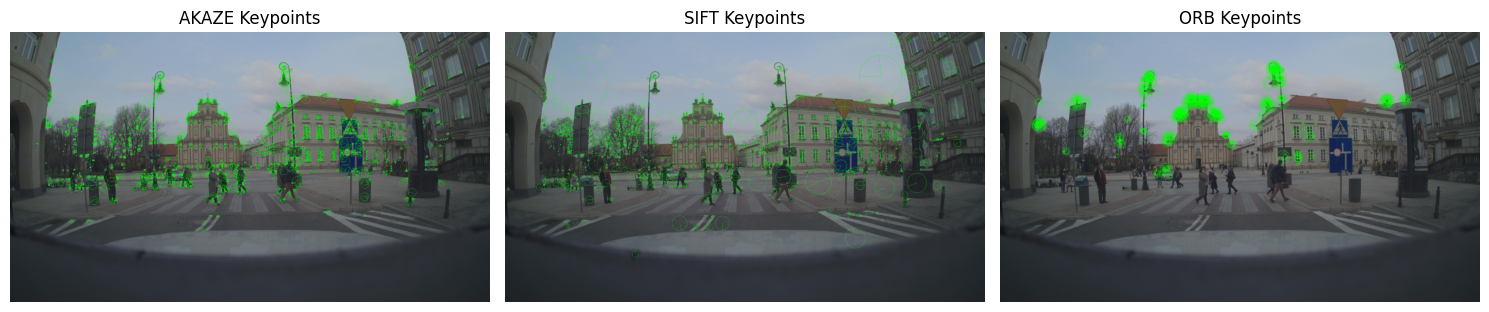

In [5]:
res_akaze = descriptor.visualize_keypoints(test_images[0], extraction_akaze)
res_sift = descriptor.visualize_keypoints(test_images[0], extraction_sift)
res_orb = descriptor.visualize_keypoints(test_images[0], extraction_orb)

plot_images([res_akaze, res_sift, res_orb], grid_shape=(1,3), figsize=(15,5), titles=['AKAZE Keypoints', 'SIFT Keypoints', 'ORB Keypoints'])

Observese cómo varían los puntos clave detectados por cada método en la misma imagen. Akaze tiende a detectar más puntos clave en texturas finas, mientras que SIFT es algo más general y ORB es rápido y eficiente para aplicaciones en tiempo real. Es interesante entonces observar como pueden influenciar transformaciones arbitrarias en la detección de puntos clave según el método empleado. Para ello, nos valemos de nuestro procesador de imagenes para aplicar diferences transformaciones y observar los resultados.

In [6]:
# Rotación de la imagen
rotated_image_processor = (ImageProcessor().add_rotation(angle_degrees=45, keep_size=True))
rotated_test_image = rotated_image_processor.process(test_images[0])

extraction_akaze_rotated = descriptor.extract(rotated_test_image, DescriptorMethod.AKAZE)
extraction_sift_rotated = descriptor.extract(rotated_test_image, DescriptorMethod.SIFT)
extraction_orb_rotated = descriptor.extract(rotated_test_image, DescriptorMethod.ORB)

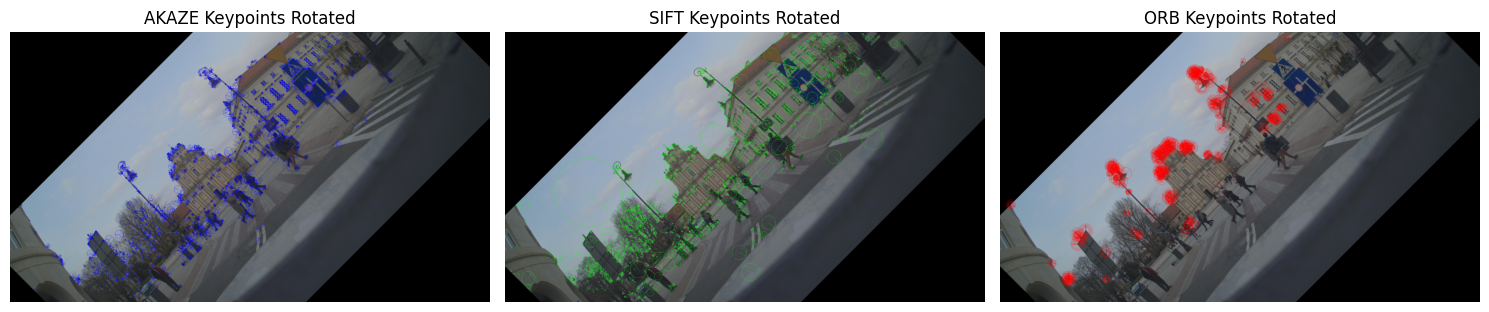

In [7]:
comparison_rotated = descriptor.visualize_comparison(rotated_test_image, [DescriptorMethod.AKAZE, DescriptorMethod.SIFT, DescriptorMethod.ORB])

plot_images(list(comparison_rotated.values()), grid_shape=(1,3), figsize=(15,5), titles=['AKAZE Keypoints Rotated', 'SIFT Keypoints Rotated', 'ORB Keypoints Rotated'])

Visualmente, se aprecia como se mantienen correctamente los puntos clave detectados tras la rotación. Veamos numericamente los resultados para obtener conclusiones más precisas.

In [8]:
numeric = descriptor.compare_methods(test_images[0], rotated_image_processor, [DescriptorMethod.AKAZE, DescriptorMethod.SIFT, DescriptorMethod.ORB])

In [9]:
for method, stats in numeric.items():
    print(f"Method: {method.name}")
    print(f"  Keypoints Original: {stats.num_keypoints_original}")
    print(f"  Keypoints Transformed: {stats.num_keypoints_transformed}")
    print(f"  Matches Found: {stats.num_matches}")
    print(f"  Num of Good Matches: {stats.num_good_matches}")
    print(f"  Repeteability: {stats.repeatability:.5f}")
    print(f"  Extraction Time: {stats.extraction_time_ms:.5f} ms")
    print()

Method: AKAZE
  Keypoints Original: 4278
  Keypoints Transformed: 3730
  Matches Found: 3186
  Num of Good Matches: 2856
  Repeteability: 0.66760
  Extraction Time: 655.05280 ms

Method: SIFT
  Keypoints Original: 6641
  Keypoints Transformed: 5552
  Matches Found: 4632
  Num of Good Matches: 4107
  Repeteability: 0.61843
  Extraction Time: 1064.23788 ms

Method: ORB
  Keypoints Original: 1000
  Keypoints Transformed: 1000
  Matches Found: 768
  Num of Good Matches: 630
  Repeteability: 0.63000
  Extraction Time: 58.84820 ms



In [10]:
comparison_sift = descriptor.visualize_matches(test_images[0], rotated_image_processor, DescriptorMethod.SIFT)
comparison_akaze = descriptor.visualize_matches(test_images[0], rotated_image_processor, DescriptorMethod.AKAZE)
comparison_orb = descriptor.visualize_matches(test_images[0], rotated_image_processor, DescriptorMethod.ORB)

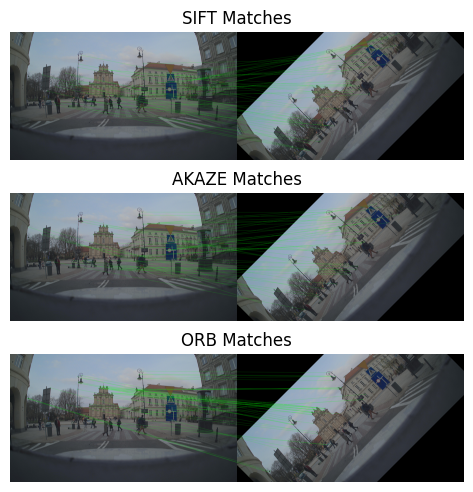

In [11]:
plot_images([comparison_sift, comparison_akaze, comparison_orb], grid_shape=(3,1), figsize=(5,5), titles=['SIFT Matches', 'AKAZE Matches', 'ORB Matches'])

Las estadíticas obtenidas muestran los siguientes datos:
- Keypoints Original: Número de puntos clave detectados en la imagen original.
- Keypoints Transformed: Número de puntos clave detectados en la imagen transformada.
- Matches Found: Número total de coincidencias encontradas entre los puntos clave de la imagen original y la transformada (se utiliza fuerza bruta en esta estadística).
- Num of Good Matches: Número de coincidencias consideradas "buenas" según un criterio de calidad de la prueba de Lowe (TODO: Referencias).
- Repeatability: Proporción de puntos clave que se mantienen consistentes entre la imagen original y la transformada.
- Extraction Time: Tiempo que tarda el método en extraer los descriptores de la imagen.

Se puede observar como los 3 métodos obtienen una repetibilidad notablemente alta, teniendo en cuenta que parte de la imagen ha sido recortada tras la rotación. Akaze es el método que mejor resultados obtiene en este caso, seguido de Orb y luego Sift. Véanse otras transformaciones para observar diferencias más notables entre los métodos.

In [12]:
noise_processor = (ImageProcessor().add_gaussian_noise(sigma=25))

noise_results = descriptor.compare_methods(test_images[0], noise_processor, [DescriptorMethod.AKAZE, DescriptorMethod.SIFT, DescriptorMethod.ORB])

In [13]:
for method, stats in noise_results.items():
    print(f"Method: {method.name}")
    print(f"  Keypoints Original: {stats.num_keypoints_original}")
    print(f"  Keypoints Transformed: {stats.num_keypoints_transformed}")
    print(f"  Matches Found: {stats.num_matches}")
    print(f"  Num of Good Matches: {stats.num_good_matches}")
    print(f"  Repeteability: {stats.repeatability:.5f}")
    print(f"  Extraction Time: {stats.extraction_time_ms:.5f} ms")
    print()

Method: AKAZE
  Keypoints Original: 4278
  Keypoints Transformed: 3764
  Matches Found: 2993
  Num of Good Matches: 2477
  Repeteability: 0.57901
  Extraction Time: 643.92157 ms

Method: SIFT
  Keypoints Original: 6641
  Keypoints Transformed: 13635
  Matches Found: 4737
  Num of Good Matches: 1978
  Repeteability: 0.29785
  Extraction Time: 1058.33312 ms

Method: ORB
  Keypoints Original: 1000
  Keypoints Transformed: 1000
  Matches Found: 662
  Num of Good Matches: 403
  Repeteability: 0.40300
  Extraction Time: 81.74306 ms



Observese que con una cantidad de ruido considerable, los métodos empiezan a mostrar diferencias notables. Sift es el que mas empeora, dejando a Akaze y Orb como los métodos más robustos frente al ruido gaussiano añadido.

In [14]:
noised_image = noise_processor.process(test_images[0])
comparison_noised = descriptor.visualize_comparison(noised_image, [DescriptorMethod.AKAZE, DescriptorMethod.SIFT, DescriptorMethod.ORB])
comparison_images = descriptor.visualize_comparison(test_images[0], [DescriptorMethod.AKAZE, DescriptorMethod.SIFT, DescriptorMethod.ORB])

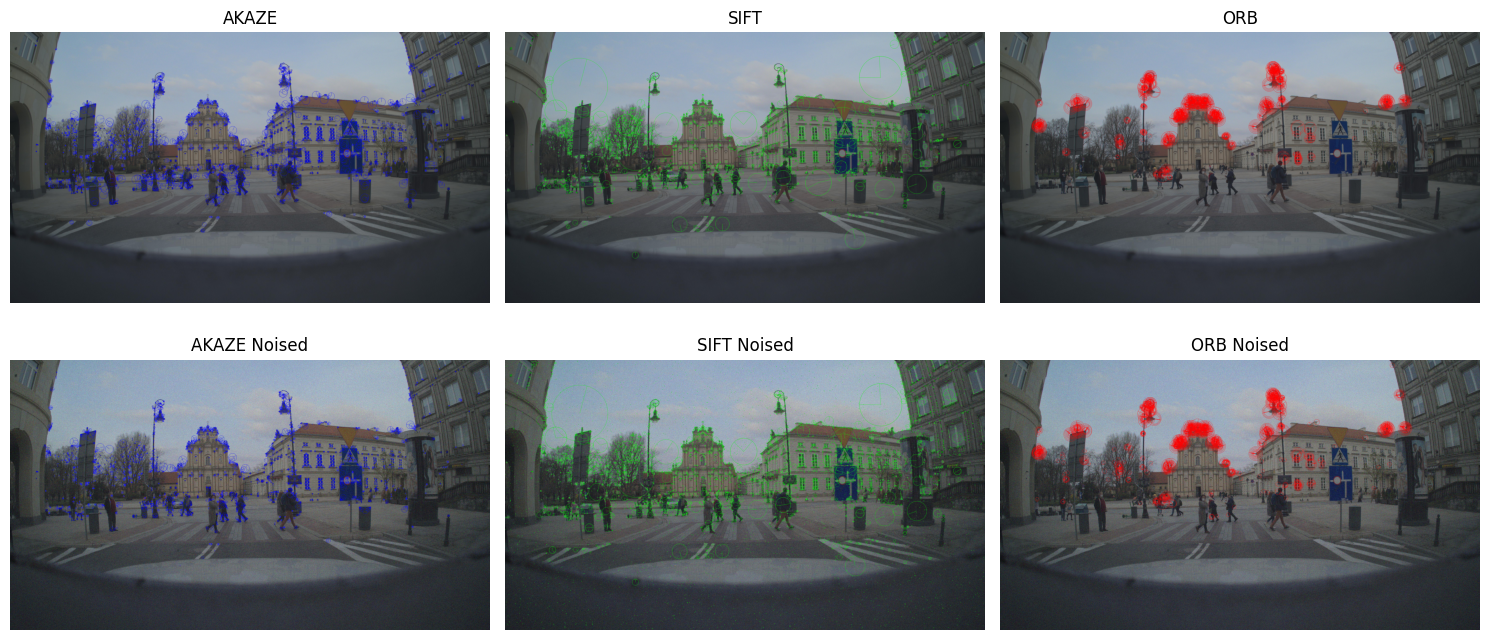

In [15]:
plot_images(list(comparison_images.values()) + list(comparison_noised.values()), grid_shape=(2,3), figsize=(15,7), titles=['AKAZE', 'SIFT', 'ORB', 'AKAZE Noised', 'SIFT Noised', 'ORB Noised'])

Es intersante ahora aplicar nuestro pipeline de procesamiento anterior, en el que podíamos segementar muy facilmente señales de tráfico basados en la saturación.

In [16]:
hsv_processor = ImageProcessor().add_into_hsv_channels().add_channel_weight('H', 'S', 0.75)

saturated_images = [hsv_processor.process(img) for img in test_images]

saturated_comps = descriptor.visualize_comparison(saturated_images[0], [DescriptorMethod.AKAZE, DescriptorMethod.SIFT, DescriptorMethod.ORB])

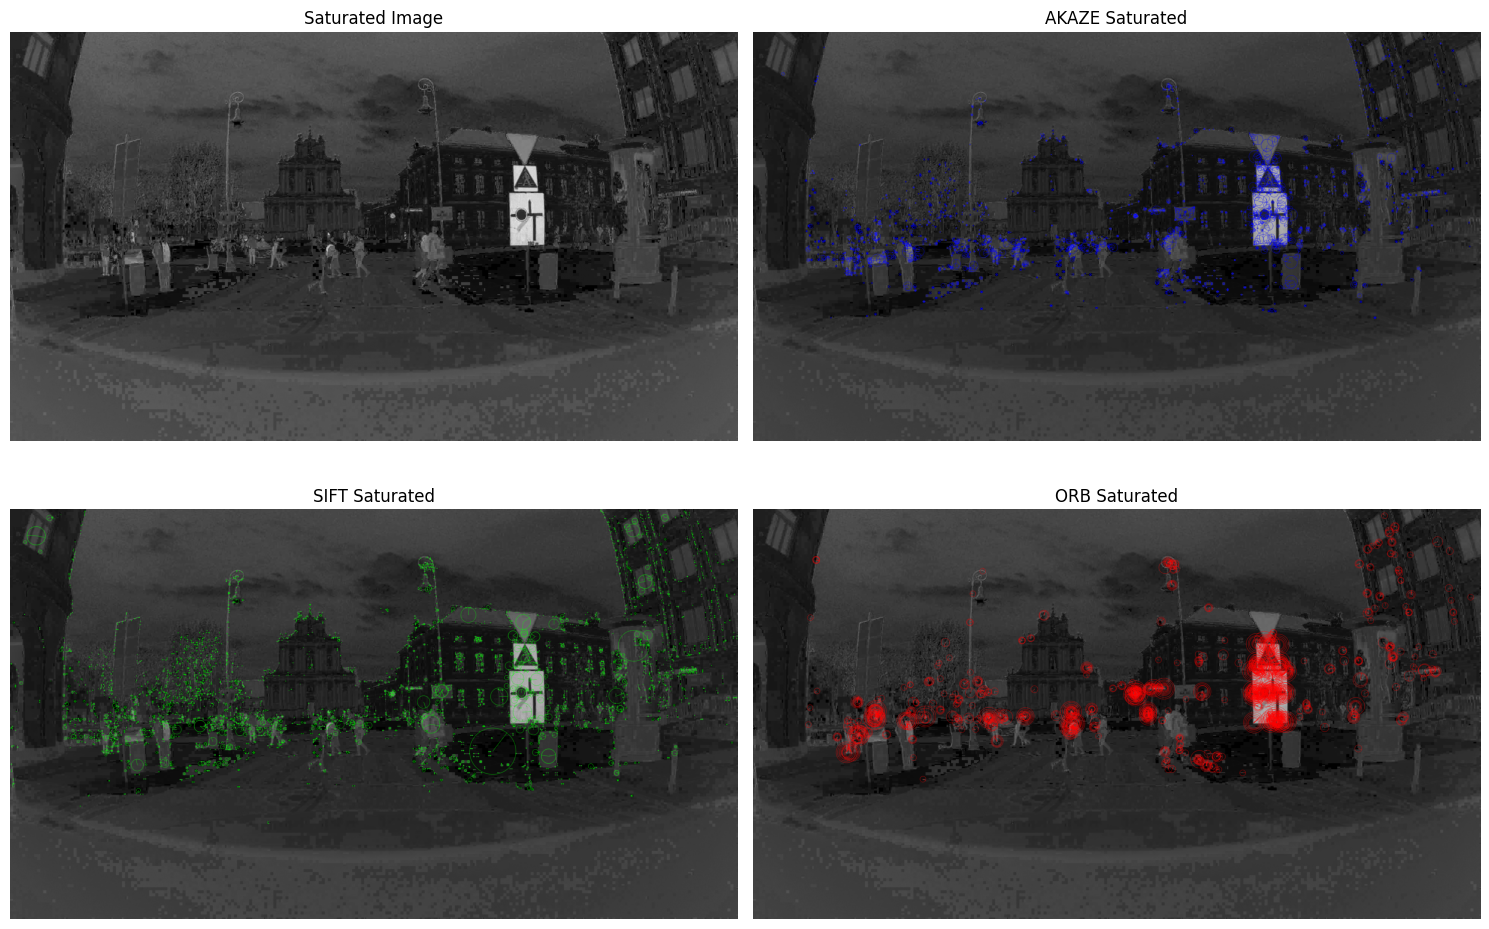

In [17]:
plot_images([saturated_images[0]] + list(saturated_comps.values()), grid_shape=(2,2), figsize=(15,10), titles=['Saturated Image', 'AKAZE Saturated', 'SIFT Saturated', 'ORB Saturated'])

Véase como ahora el extractor los extractores de descpriptores cambian su comportamiento, enfocandose en zonas alog mas relevantes de la imagen tras el procesamiento previo. Probando con la transformación de color y obtención de bordes.

In [18]:
color_procesor = (ImageProcessor().add_into_hsv_channels().add_red_blue_filter().add_filter_connected_components(min_size=20))
dilator = ImageProcessor().add_dilate_edges(kernel_size=3, iterations=1)
fuser = ImageFuser()

color_processed_image = color_procesor.process(test_images[0])
dilate = dilator.process(color_processed_image)
color_processed_image = fuser.subtract(dilate, color_processed_image)

color_comps = descriptor.visualize_comparison(color_processed_image, [DescriptorMethod.AKAZE, DescriptorMethod.SIFT, DescriptorMethod.ORB])

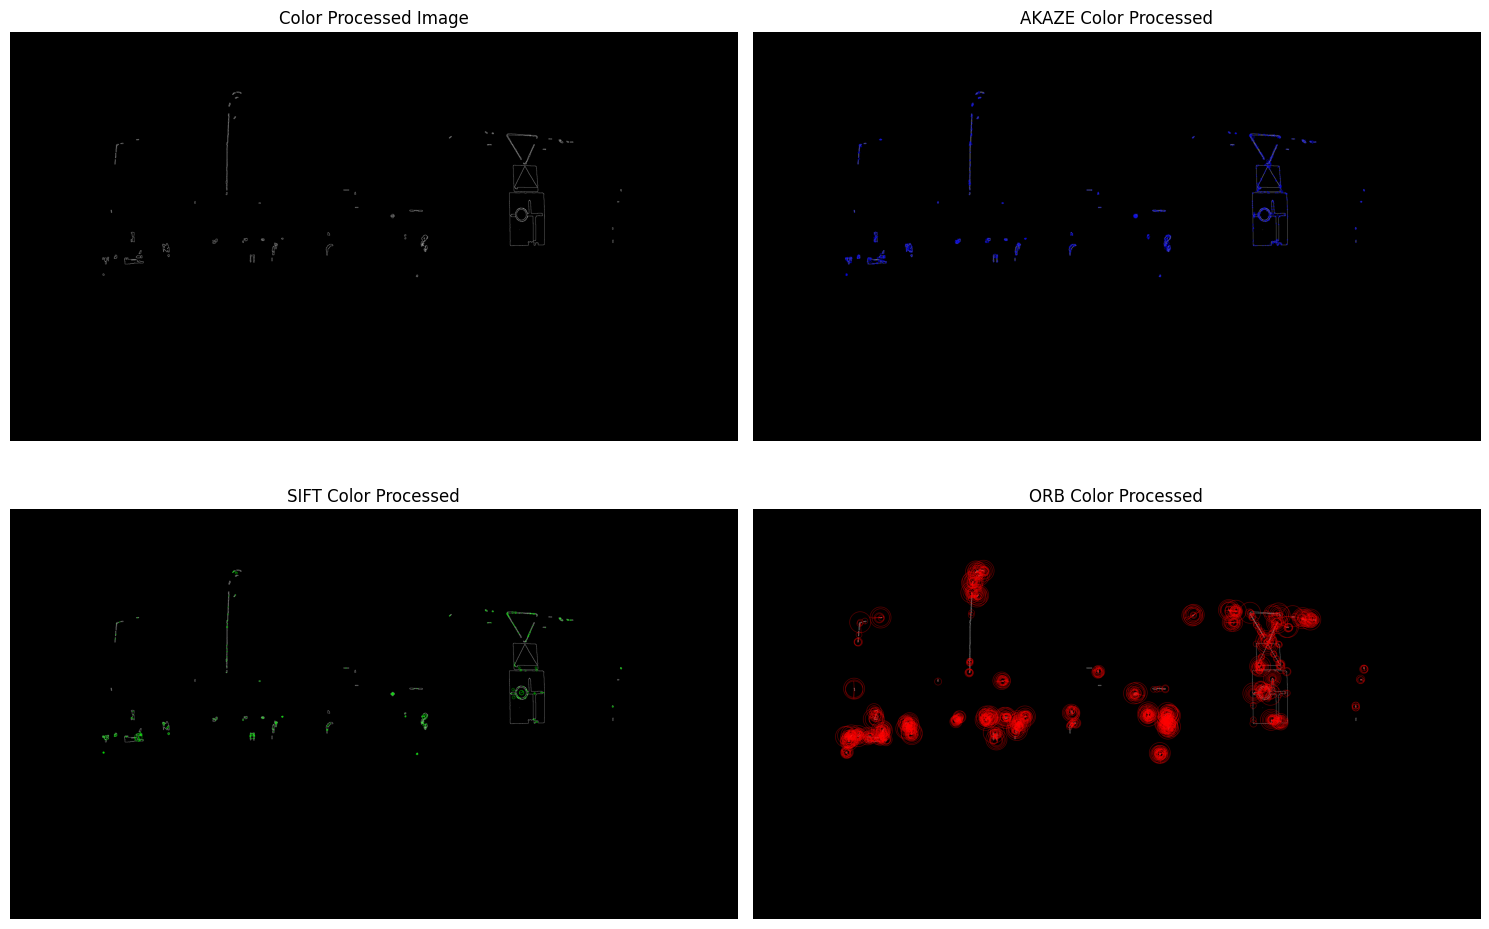

In [19]:
plot_images([color_processed_image] + list(color_comps.values()), grid_shape=(2,2), figsize=(15,10), titles=['Color Processed Image', 'AKAZE Color Processed', 'SIFT Color Processed', 'ORB Color Processed'])

Véase como nos podemos centrar en características más relevantes de la imagen tras el procesamiento previo. Probando con la transformación de color y obtención de bordes. Los puntos clave se centran en nuestras conas de interese, que concentran las señales de tráfico.

# Matching de descriptores

Una vez que hemos extraido los descriptores locales, podemos hacer matching de los mismos entre diferentes imágenes. Para ello, hemos creado una clase `SignMatcher`que cargará una serie de imágenes de referencia y permitirá hacer matching de descriptores extraidos de nuevas imágenes contra los descriptores de las imágenes de referencia, devolviendo las mejores coincidencias encontradas. Nuestro matcher, puede utilizar tanto FlannBased como BruteForce como método de matching.

Probaremos primero cargando las imagenes anteriores como referencia, para luego ver cuales puede emparejar según sus matches. Nuestro matcher toma las imagenes de referencia, extrae las zonas de relevancia que venían etiquetadas y se guarda las subimágenes correspondientes a las señales de tráfico para luego extraer sus descriptores.

In [69]:
matcher = SignMatcher("./images/bt3/test", method=DescriptorMethod.AKAZE, matcher_type=MatcherType.FLANN)

Loading image from images/bt3/test/000014/camera_front_blur/000014_india_2021-04-18T15:57:58.885517Z.jpg
Loading image from images/bt3/test/000177/camera_front_blur/000177_golf_2021-04-26T09:01:16.995578Z.jpg
Loading image from images/bt3/test/000205/camera_front_blur/000205_india_2021-04-29T13:26:40.774894Z.jpg
Loading image from images/bt3/test/000247/camera_front_blur/000247_golf_2021-04-27T10:58:38.108810Z.jpg
Loading image from images/bt3/test/020539/camera_front_blur/020539_india_2020-04-24T13:34:24.775134Z.jpg
Loading image from images/bt3/test/020541/camera_front_blur/020541_india_2020-03-31T11:09:20.113995Z.jpg
Loading image from images/bt3/test/020567/camera_front_blur/020567_india_2020-07-27T13:01:18.890907Z.jpg
Loading image from images/bt3/test/020578/camera_front_blur/020578_oscar_2021-04-15T08:41:33.109881Z.jpg
Loading image from images/bt3/test/020579/camera_front_blur/020579_india_2020-07-22T08:47:24.215579Z.jpg
Loading image from images/bt3/test/020604/camera_front_bl

In [70]:
match_results = matcher.match(test_images[1])
print(match_results)

[MatchResult(000247_8: 0.5%, 31 matches), MatchResult(000247_36: 0.5%, 27 matches), MatchResult(020567_10: 0.4%, 26 matches)]


In [71]:
names = [ m.reference_name for m in match_results]
visualizations = [matcher.visualize_match(test_images[1], name) for name in names]

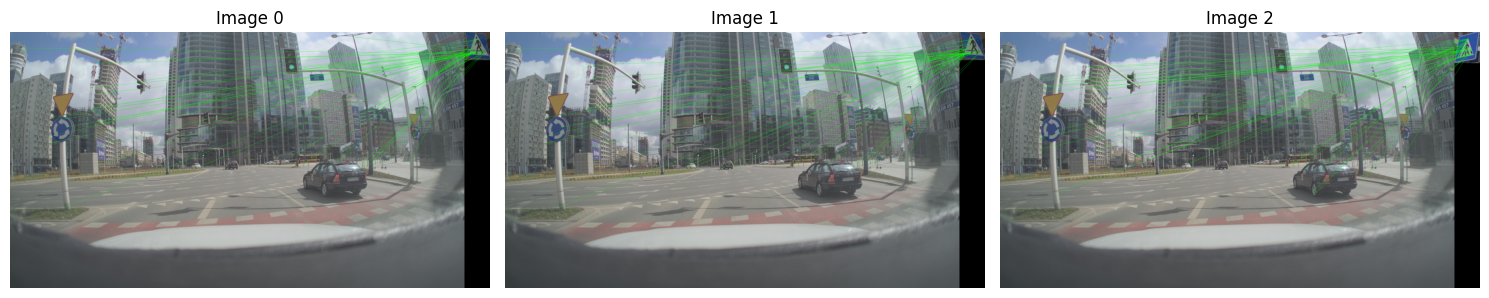

In [72]:
plot_images(visualizations, grid_shape=(1,3), figsize=(15,5))

In [73]:
template_image = matcher.get_reference_image('000177_4')
localizations = matcher.locate_template_batch(template_image, test_images)
visualizations = matcher.visualize_localization_batch(template_image, test_images, localizations)
visualizations = [vis for vis in visualizations if vis is not None]

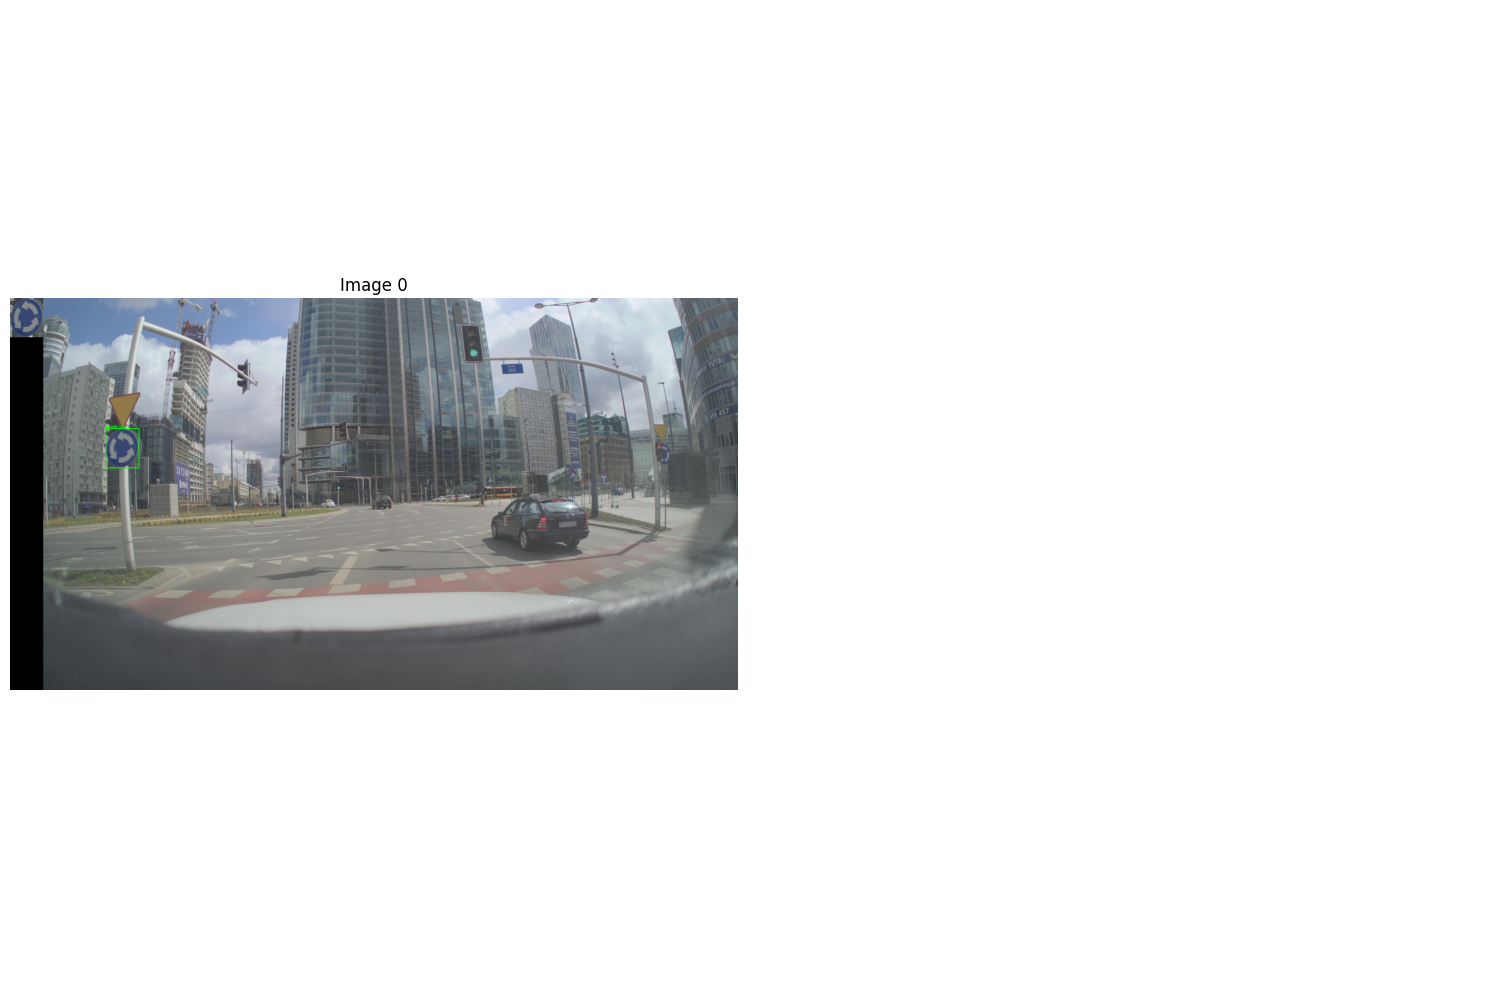

In [74]:
plot_images(visualizations, grid_shape=(1, 2), figsize=(15,10))

In [75]:
def pre_process_image(image):
    processor = (ImageProcessor()
                 .add_into_hsv_channels()
                 .add_red_blue_filter()
                 .add_filter_connected_components(min_size=20))
    dilator = ImageProcessor().add_dilate_edges(kernel_size=3, iterations=1)
    fuser = ImageFuser()
    processed = processor.process(image)
    dilated = dilator.process(processed)
    final_image = fuser.subtract(dilated, processed)

    return final_image

In [76]:
preprocess_matcher = SignMatcher("./images/bt3/test", method=DescriptorMethod.AKAZE, matcher_type=MatcherType.FLANN, preprocessor=pre_process_image)

Loading image from images/bt3/test/000014/camera_front_blur/000014_india_2021-04-18T15:57:58.885517Z.jpg
Loading image from images/bt3/test/000177/camera_front_blur/000177_golf_2021-04-26T09:01:16.995578Z.jpg
Loading image from images/bt3/test/000205/camera_front_blur/000205_india_2021-04-29T13:26:40.774894Z.jpg
Loading image from images/bt3/test/000247/camera_front_blur/000247_golf_2021-04-27T10:58:38.108810Z.jpg
Loading image from images/bt3/test/020539/camera_front_blur/020539_india_2020-04-24T13:34:24.775134Z.jpg
Loading image from images/bt3/test/020541/camera_front_blur/020541_india_2020-03-31T11:09:20.113995Z.jpg
Loading image from images/bt3/test/020567/camera_front_blur/020567_india_2020-07-27T13:01:18.890907Z.jpg
Loading image from images/bt3/test/020578/camera_front_blur/020578_oscar_2021-04-15T08:41:33.109881Z.jpg
Loading image from images/bt3/test/020579/camera_front_blur/020579_india_2020-07-22T08:47:24.215579Z.jpg
Loading image from images/bt3/test/020604/camera_front_bl

In [77]:
match_results = preprocess_matcher.match(test_images[1])
print(match_results)

[MatchResult(000177_4: 3.5%, 91 matches), MatchResult(000177_37: 3.4%, 90 matches), MatchResult(000177_46: 2.2%, 58 matches)]


In [78]:
names = [ m.reference_name for m in match_results]
visualizations = [ preprocess_matcher.visualize_match(test_images[1], name) for name in names]

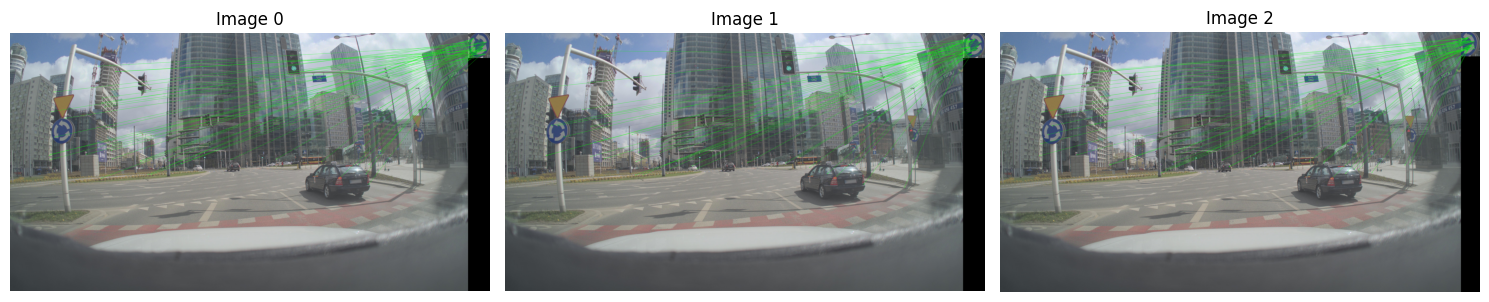

In [79]:
plot_images(visualizations, grid_shape=(1,3), figsize=(15,5))

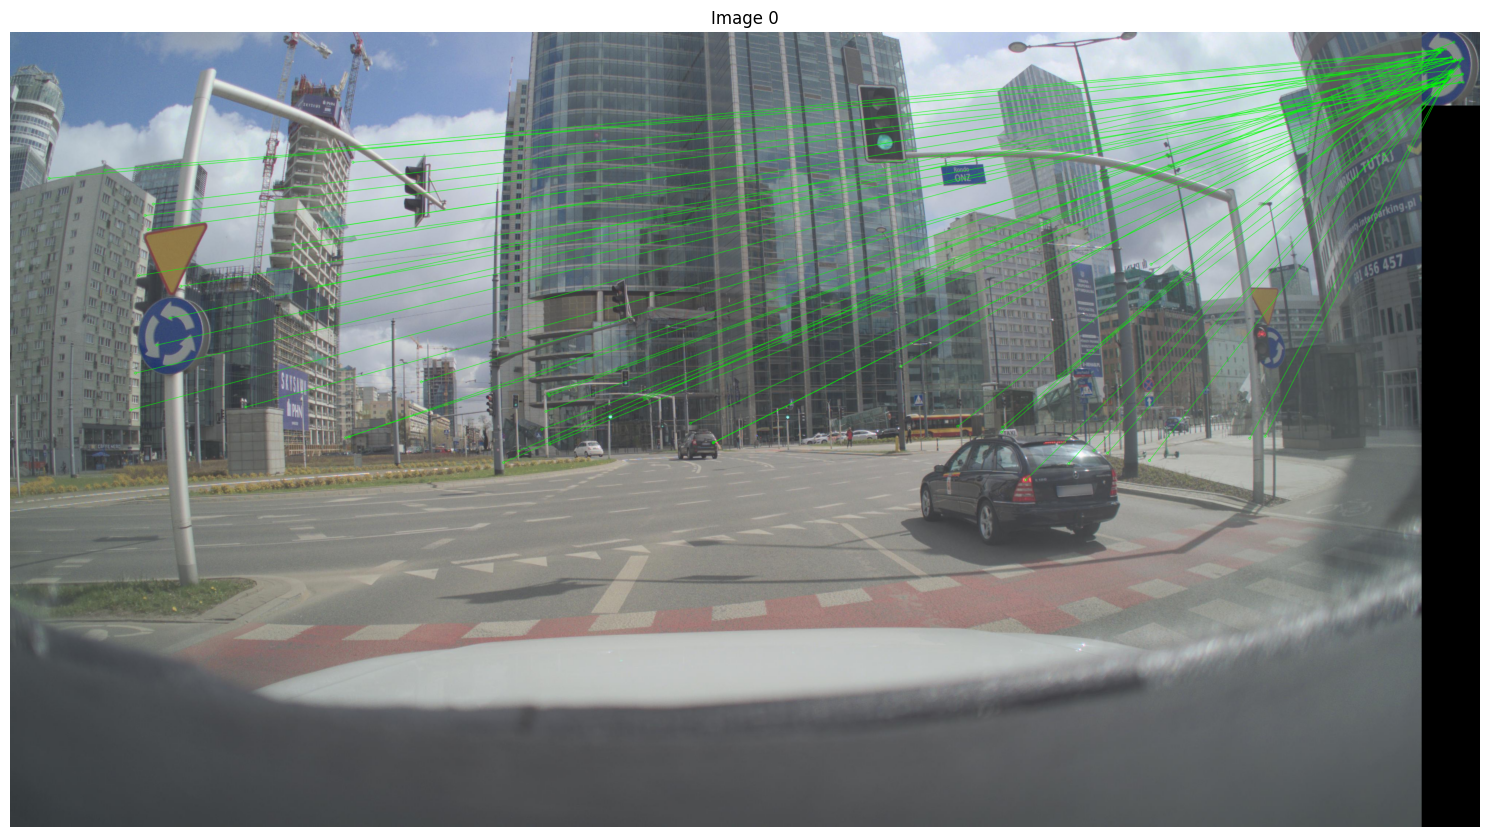

In [80]:
plot_images([visualizations[2]], grid_shape=(1,1), figsize=(15,15))

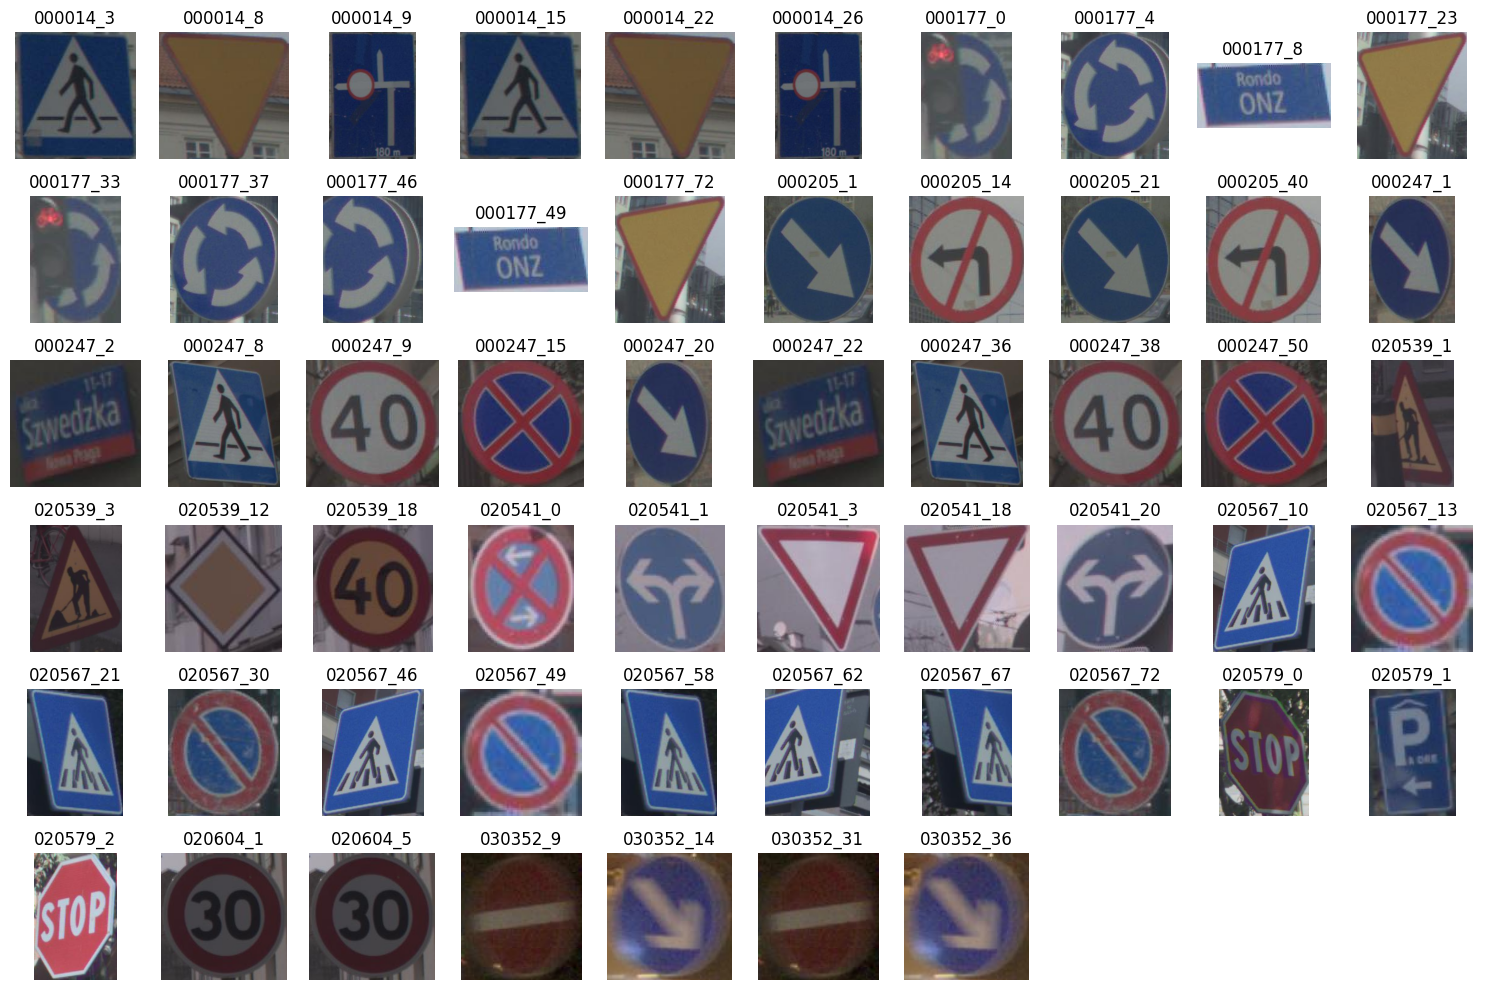

In [81]:
ref_images = [ d[1] for d in preprocess_matcher._references ]
ref_titles = [ d[0] for d in preprocess_matcher._references ]
plot_images(ref_images, titles=ref_titles, grid_shape=(6,10), figsize=(15,10))

In [ ]:
template_image = preprocess_matcher.get_reference_image('000014_8')
localizations = preprocess_matcher.locate_template_batch(template_image, test_images)
visualizations = preprocess_matcher.visualize_localization_batch(template_image, test_images, localizations)
visualizations = [vis for vis in visualizations if vis is not None]

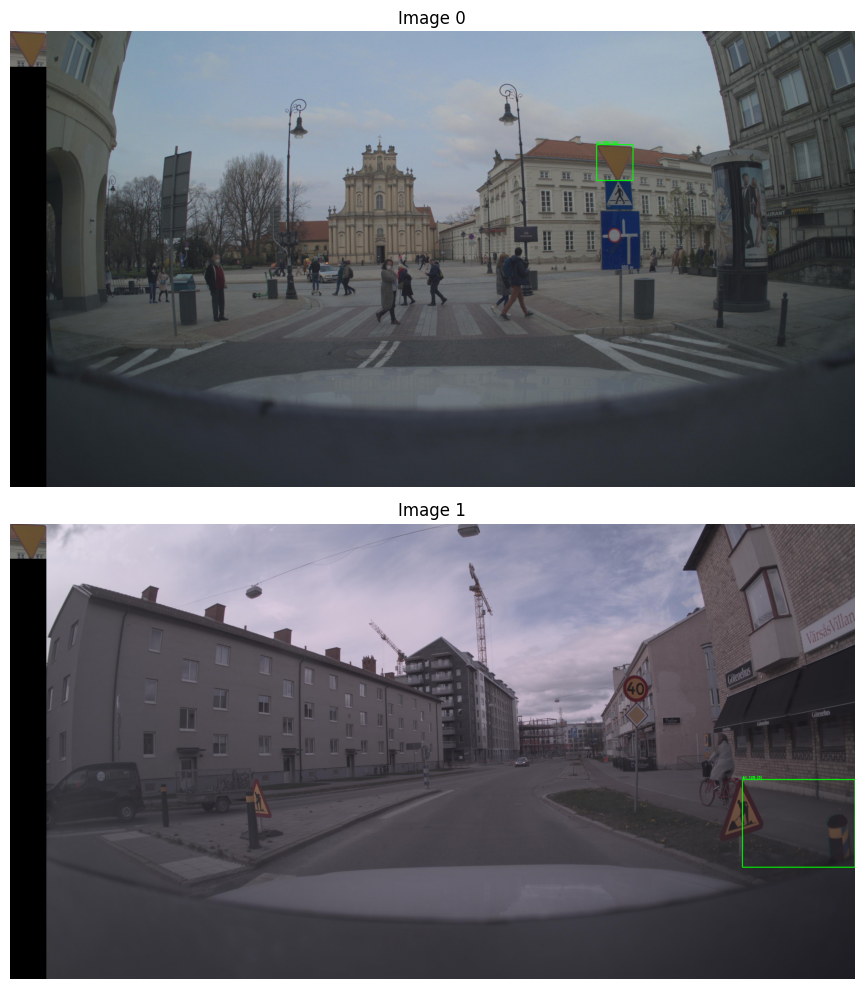

In [83]:
plot_images(visualizations, grid_shape=(2, 1), figsize=(15,10))